## Beginner Notebook: Dense Autoencoder on MNIST

In this notebook, we build a simple dense autoencoder that learns to reconstruct handwritten digit images from the MNIST dataset.

The model compresses each image from **784 pixel values** into a smaller **32-dimensional bottleneck representation**, then reconstructs the original image.

**Architecture:**  
`Input(784) → Dense(128) → Dense(32) → Dense(128) → Dense(784)`

**Goal:**  
Train the autoencoder to make the reconstructed image as close as possible to the original image.

In [1]:
# ============================================================
# Learning Day 6: Autoencoders Fundamentals
# Beginner Notebook: Dense Autoencoder on MNIST
# Step 1: Import libraries and check environment
# ============================================================

# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt

# TensorFlow / Keras for building the autoencoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility: helps us get similar results each time
np.random.seed(42)
tf.random.set_seed(42)

# Display basic environment information
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Check whether GPU is available
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)

if gpus:
    print("GPU device:", gpus[0].name)
else:
    print("Running on CPU")

2026-06-04 21:05:24.710415: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
NumPy version: 1.26.4
GPU available: False
Running on CPU


## 1. Load and Inspect the MNIST Dataset

MNIST contains grayscale images of handwritten digits from 0 to 9.

Each image has a size of **28 × 28 pixels**.  
Before preprocessing, we will load the dataset and inspect the shapes of the training and test sets.

In [3]:
# ============================================================
# Step 2: Load and inspect the MNIST dataset
# ============================================================

# Load MNIST dataset from Keras
# x_train and x_test contain digit images
# y_train and y_test contain digit labels, but autoencoders do not use labels for training

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Print dataset shapes

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Print pixel value range before normalization

print("\nPixel value range before normalization:")
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

# Show first 10 labels only for understanding the dataset
# These labels are NOT used by the autoencoder during training

print("\nFirst 10 training labels:")
print(y_train[:10])

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range before normalization:
Minimum pixel value: 0
Maximum pixel value: 255

First 10 training labels:
[5 0 4 1 9 2 1 3 1 4]


## 2. Visual Inspection of MNIST Images

Before preprocessing, we inspect a few sample images to understand what the dataset looks like.

The labels are shown only for human understanding.  
The autoencoder itself will not use these labels during training.

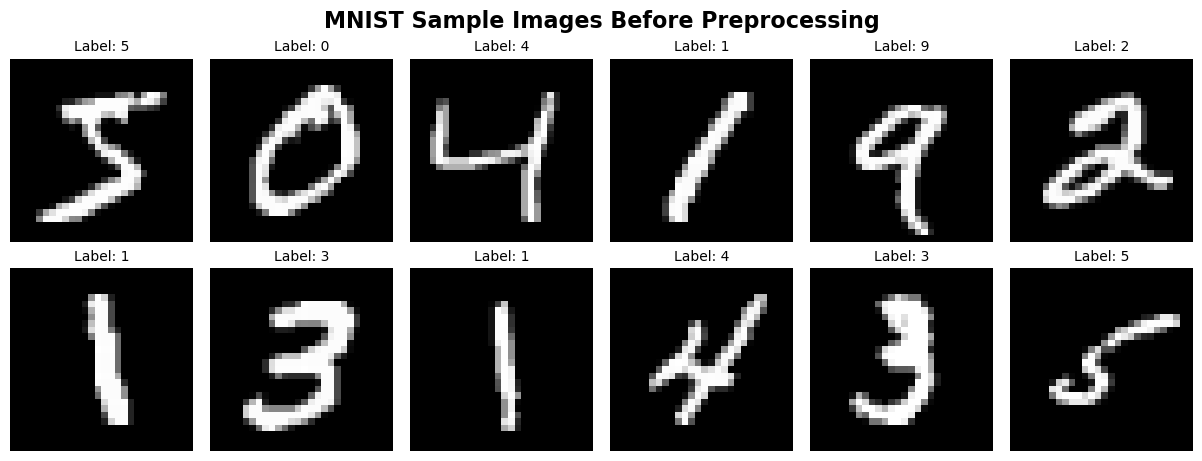

Single image shape: (28, 28)
Single image data type: uint8
Pixel range in first sample image: 0 to 255


In [ ]:
# ============================================================
# Step 3: Visualize sample MNIST images
# ============================================================

# Select first 12 images for quick visual inspection

num_images = 12
sample_images = x_train[:num_images]
sample_labels = y_train[:num_images]

# Create a clean image grid
fig, axes = plt.subplots(
    nrows=2,
    ncols=6,
    figsize=(12, 4.5),
    constrained_layout=True
)

fig.suptitle(
    "MNIST Sample Images Before Preprocessing",
    fontsize=16,
    fontweight="bold"
)

# Plot each image
for ax, image, label in zip(axes.ravel(), sample_images, sample_labels):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis("off")

plt.show()

# Print technical details for one sample image
print("Single image shape:", sample_images[0].shape)
print("Single image data type:", sample_images[0].dtype)
print("Pixel range in first sample image:", sample_images[0].min(), "to", sample_images[0].max())

## 3. Preprocess MNIST Images

For the dense autoencoder, each 28 × 28 image is converted into a flat row of 784 pixel values.

We also normalise pixel values from **0–255** to **0–1**, because the output layer uses a sigmoid activation.

In [ ]:
# ============================================================
# Step 4: Normalize and flatten MNIST images
# ============================================================

# Normalize pixel values from 0-255 to 0-1
# This helps the neural network train more smoothly

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Flatten each 28x28 image into a 784-value row
# Dense layers expect this flat format

x_train_flat = x_train_norm.reshape((x_train_norm.shape[0], 28 * 28))
x_test_flat = x_test_norm.reshape((x_test_norm.shape[0], 28 * 28))

# Print shape changes
print("Original training shape:", x_train.shape)
print("Normalized training shape:", x_train_norm.shape)
print("Flattened training shape:", x_train_flat.shape)

print("\nOriginal test shape:", x_test.shape)
print("Normalized test shape:", x_test_norm.shape)
print("Flattened test shape:", x_test_flat.shape)

# Confirm new pixel range
print("\nPixel value range after normalization:")
print("Training min:", x_train_flat.min())
print("Training max:", x_train_flat.max())
print("Test min:", x_test_flat.min())
print("Test max:", x_test_flat.max())

Original training shape: (60000, 28, 28)
Normalized training shape: (60000, 28, 28)
Flattened training shape: (60000, 784)

Original test shape: (10000, 28, 28)
Normalized test shape: (10000, 28, 28)
Flattened test shape: (10000, 784)

Pixel value range after normalization:
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


- 60000 training images → each converted to 784 values
- 10000 test images → each converted to 784 values
- Pixel range → 0.0 to 1.0

## 4. Build the Dense Autoencoder

The autoencoder has three main parts:

- **Input layer:** receives the flattened 784-pixel image
- **Encoder:** compresses the image into a 32-dimensional bottleneck
- **Decoder:** reconstructs the image back to 784 pixels

The final output uses **sigmoid**, so each reconstructed pixel stays between 0 and 1.

In [ ]:
# ============================================================
# Step 5: Build the dense autoencoder model
# Architecture: 784 → 128 → 32 → 128 → 784
# ============================================================

# Define important dimensions

input_dim = 784          # 28 x 28 pixels flattened
hidden_dim = 128         # hidden layer size
bottleneck_dim = 32      # compressed representation size

# -----------------------------
# Encoder
# -----------------------------

# Input layer receives one flattened MNIST image

input_image = keras.Input(shape=(input_dim,), name="input_image")

# First dense layer compresses 784 pixel values into 128 learned features

encoded_128 = layers.Dense(
    hidden_dim,
    activation="relu",
    name="encoder_dense_128"
)(input_image)

# Bottleneck layer compresses 128 features into only 32 values

bottleneck = layers.Dense(
    bottleneck_dim,
    activation="relu",
    name="bottleneck_32"
)(encoded_128)

# -----------------------------
# Decoder
# -----------------------------

# Decoder expands the 32-value bottleneck back to 128 features

decoded_128 = layers.Dense(
    hidden_dim,
    activation="relu",
    name="decoder_dense_128"
)(bottleneck)

# Final layer reconstructs the original 784 pixel values
# Sigmoid keeps output values between 0 and 1

reconstructed_image = layers.Dense(
    input_dim,
    activation="sigmoid",
    name="reconstructed_output"
)(decoded_128)

# -----------------------------
# Full autoencoder model
# -----------------------------

autoencoder = keras.Model(
    inputs=input_image,
    outputs=reconstructed_image,
    name="dense_autoencoder_mnist"
)

# Separate encoder model: useful later if we want the 32-value compressed code

encoder = keras.Model(
    inputs=input_image,
    outputs=bottleneck,
    name="encoder_model"
)

# Print model structure
autoencoder.summary()

Model: "dense_autoencoder_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_128 (Dense)       │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_32 (Dense)           │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_128 (Dense)       │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Dense)    │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

### Preprocessing and Model Setup — Conclusion

The MNIST images were successfully loaded, normalised 

from **0–255** to **0–1**, and flattened from **28 × 28** into **784 pixel values**.

A dense autoencoder was built with the required architecture:

`784 → 128 → 32 → 128 → 784`

The **32-neuron bottleneck layer** forces the model to learn a compressed representation of each digit before reconstructing the original image.

## 5. Compile the Autoencoder

Before training, the autoencoder must be compiled.

Compilation tells Keras two important things:

- **Optimizer:** how the model should update its weights  
- **Loss function:** how the model should measure reconstruction error

For this beginner autoencoder, we use:

- **Adam optimizer** — updates model weights efficiently
- **Binary Crossentropy loss** — compares original pixels with reconstructed pixels after normalisation to the 0–1 range

In [7]:
# ============================================================
# Step 6: Compile the autoencoder
# ============================================================

# Compile the model before training
# Optimizer: Adam = smart weight updater
# Loss: binary_crossentropy = measures pixel reconstruction error for 0-1 pixel values
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("Autoencoder compiled successfully.")
print("Optimizer: Adam")
print("Loss function: Binary Crossentropy")

Autoencoder compiled successfully.
Optimizer: Adam
Loss function: Binary Crossentropy


### Model Compilation — Conclusion

The autoencoder is now ready for training.

It will use the **Adam optimizer** to update weights 

and **Binary Crossentropy** to measure how different the reconstructed image is from the original image.

## 6. Train the Dense Autoencoder

The model will now learn to reconstruct MNIST images.

Because this is an autoencoder, the input and target are the same:

`x_train_flat → x_train_flat`

This means the model receives a digit image and learns to rebuild that same digit image.

In [8]:
# ============================================================
# Step 7: Train the dense autoencoder
# ============================================================

# Train the autoencoder
# Input  = x_train_flat
# Target = x_train_flat
# This teaches the model to reconstruct its own input

history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)

print("Training completed.")

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2292 - val_loss: 0.1495
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1346 - val_loss: 0.1214
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1163 - val_loss: 0.1094
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1076 - val_loss: 0.1032
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1028 - val_loss: 0.0997
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0998 - val_loss: 0.0974
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0977 - val_loss: 0.0955
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0960 - val_loss: 0.0942
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0947 - val_loss: 0.0931
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0936 - val_loss: 0.0921
Training completed.


## 6. Train the Dense Autoencoder

The autoencoder is trained to reconstruct its own input.

For this reason, both the input and target are the same:

`x_train_flat → x_train_flat`

The model will train for **10 epochs**, using mini-batches of **256 images**, and validation loss will be checked on the test set after each epoch.

In [9]:
# ============================================================
# Step 7: Train the dense autoencoder
# ============================================================

history = autoencoder.fit(
    x_train_flat,                 # Input images
    x_train_flat,                 # Target images are the same for reconstruction
    epochs=10,                    # Number of full passes through the training data
    batch_size=256,               # Number of images processed before each weight update
    shuffle=True,                 # Shuffle images each epoch for better learning
    validation_data=(
        x_test_flat,              # Validation input images
        x_test_flat               # Validation target images
    ),
    verbose=1                     # Show training progress
)

print("Training completed.")

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0927 - val_loss: 0.0913
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0920 - val_loss: 0.0907
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0913 - val_loss: 0.0901
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0908 - val_loss: 0.0897
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0903 - val_loss: 0.0892
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0899 - val_loss: 0.0889
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0895 - val_loss: 0.0885
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0891 - val_loss: 0.0882
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0888 - val_loss: 0.0880
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0885 - val_loss: 0.0877
Training completed.


## 7. Visualise Training Performance

The loss curve shows whether the autoencoder improved during training.

- **Training loss** shows reconstruction error on training images.
- **Validation loss** shows reconstruction error on unseen test images.

A good result is when both curves decrease smoothly and stay close to each other.

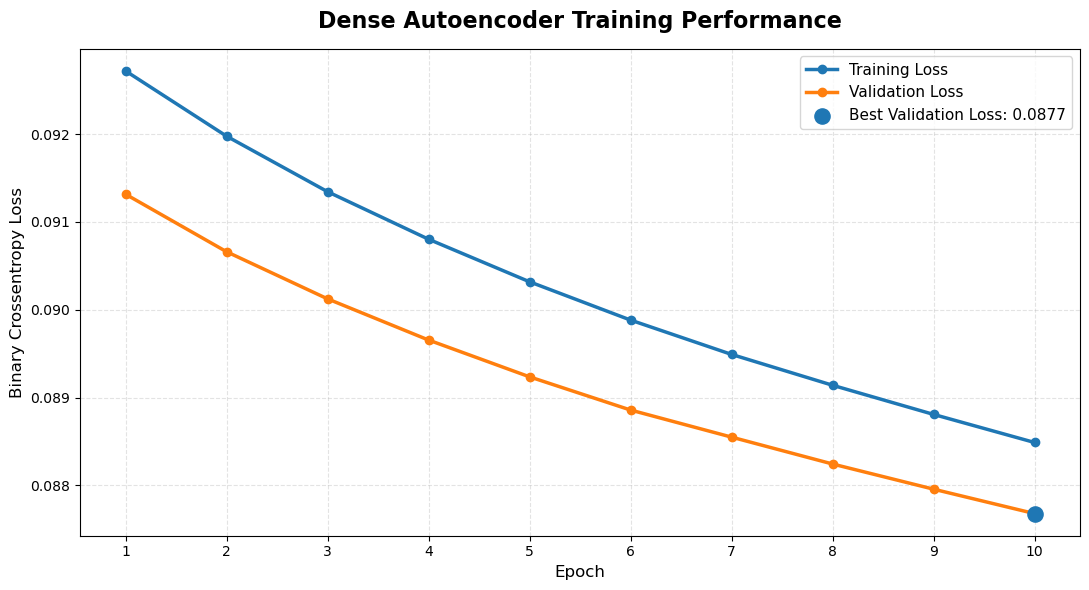

Final training loss: 0.0885
Final validation loss: 0.0877
Best validation loss: 0.0877 at epoch 10


In [10]:
# ============================================================
# Step 8: Plot training and validation loss
# ============================================================

# Convert Keras training history into a DataFrame for easier plotting
history_df = pd.DataFrame(history.history)

# Add epoch numbers starting from 1
history_df["epoch"] = range(1, len(history_df) + 1)

# Identify best validation loss
best_epoch = history_df["val_loss"].idxmin() + 1
best_val_loss = history_df["val_loss"].min()

# Create a polished loss curve
plt.figure(figsize=(11, 6))

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    marker="o",
    linewidth=2.5,
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    linewidth=2.5,
    label="Validation Loss"
)

# Highlight best validation loss point
plt.scatter(
    best_epoch,
    best_val_loss,
    s=120,
    zorder=5,
    label=f"Best Validation Loss: {best_val_loss:.4f}"
)

plt.title(
    "Dense Autoencoder Training Performance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Crossentropy Loss", fontsize=12)

plt.xticks(history_df["epoch"])
plt.grid(True, linestyle="--", alpha=0.35)

plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

# Display final loss values clearly
print("Final training loss:", round(history_df["loss"].iloc[-1], 4))
print("Final validation loss:", round(history_df["val_loss"].iloc[-1], 4))
print("Best validation loss:", round(best_val_loss, 4), "at epoch", best_epoch)

### Training Performance — Conclusion

The dense autoencoder trained successfully for 10 epochs.

Both training loss and validation loss decreased smoothly, 

which shows that the model learned to reconstruct MNIST digits better over time.

The validation loss also decreased, so there is no clear sign of overfitting in this beginner experiment.

## 8. Generate Reconstructed Images

After training, we use the autoencoder to reconstruct unseen MNIST test images.

The reconstructed images will be compared with the original images to understand what information the bottleneck preserved and what details were lost.

In [11]:
# ============================================================
# Step 9: Generate reconstructed images from the test set
# ============================================================

# Use the trained autoencoder to reconstruct test images
# Input: flattened test images with shape (10000, 784)
# Output: reconstructed flattened images with shape (10000, 784)
reconstructed_flat = autoencoder.predict(
    x_test_flat,
    batch_size=256,
    verbose=1
)

# Reshape reconstructed images back from 784 values to 28x28 image format
reconstructed_images = reconstructed_flat.reshape((-1, 28, 28))

# Calculate reconstruction error per image using Mean Squared Error
# This tells us how different each reconstructed image is from its original image
reconstruction_errors = np.mean(
    np.square(x_test_norm - reconstructed_images),
    axis=(1, 2)
)

# Display shape and error summary
print("Original test image shape:", x_test_norm.shape)
print("Reconstructed image shape:", reconstructed_images.shape)
print("\nAverage reconstruction error:", round(reconstruction_errors.mean(), 6))
print("Minimum reconstruction error:", round(reconstruction_errors.min(), 6))
print("Maximum reconstruction error:", round(reconstruction_errors.max(), 6))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Original test image shape: (10000, 28, 28)
Reconstructed image shape: (10000, 28, 28)

Average reconstruction error: 0.008549
Minimum reconstruction error: 0.000511
Maximum reconstruction error: 0.041304


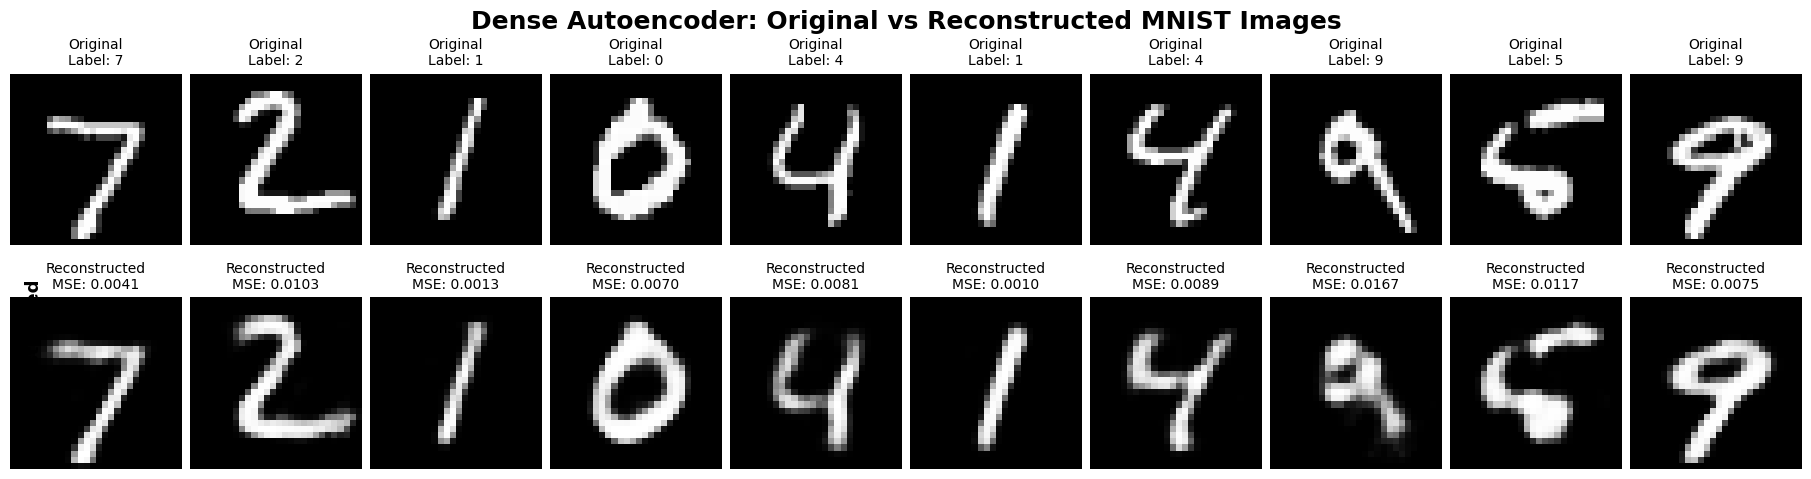

In [12]:
# ============================================================
# Step 10: Visualize original vs reconstructed MNIST images
# ============================================================

# Number of images to display
num_images = 10

# Select the first 10 test images
original_samples = x_test_norm[:num_images]
reconstructed_samples = reconstructed_images[:num_images]
sample_errors = reconstruction_errors[:num_images]
sample_labels = y_test[:num_images]

# Create a 2-row grid:
# Row 1 = original images
# Row 2 = reconstructed images
fig, axes = plt.subplots(
    nrows=2,
    ncols=num_images,
    figsize=(18, 4.8),
    constrained_layout=True
)

fig.suptitle(
    "Dense Autoencoder: Original vs Reconstructed MNIST Images",
    fontsize=18,
    fontweight="bold"
)

# Plot original images in the first row
for i in range(num_images):
    axes[0, i].imshow(original_samples[i], cmap="gray")
    axes[0, i].set_title(f"Original\nLabel: {sample_labels[i]}", fontsize=10)
    axes[0, i].axis("off")

# Plot reconstructed images in the second row
for i in range(num_images):
    axes[1, i].imshow(reconstructed_samples[i], cmap="gray")
    axes[1, i].set_title(f"Reconstructed\nMSE: {sample_errors[i]:.4f}", fontsize=10)
    axes[1, i].axis("off")

# Add row labels on the left side
fig.text(
    0.01, 0.68, "Original",
    fontsize=13,
    fontweight="bold",
    rotation=90,
    va="center"
)

fig.text(
    0.01, 0.28, "Reconstructed",
    fontsize=13,
    fontweight="bold",
    rotation=90,
    va="center"
)

plt.show()

## 9. Visualise Reconstruction Error Maps

To better understand where the autoencoder loses detail, we create an error map.

The error map shows the absolute pixel-level difference between the original image and the reconstructed image.

Brighter areas in the error map mean the model made a larger reconstruction mistake in that part of the image.

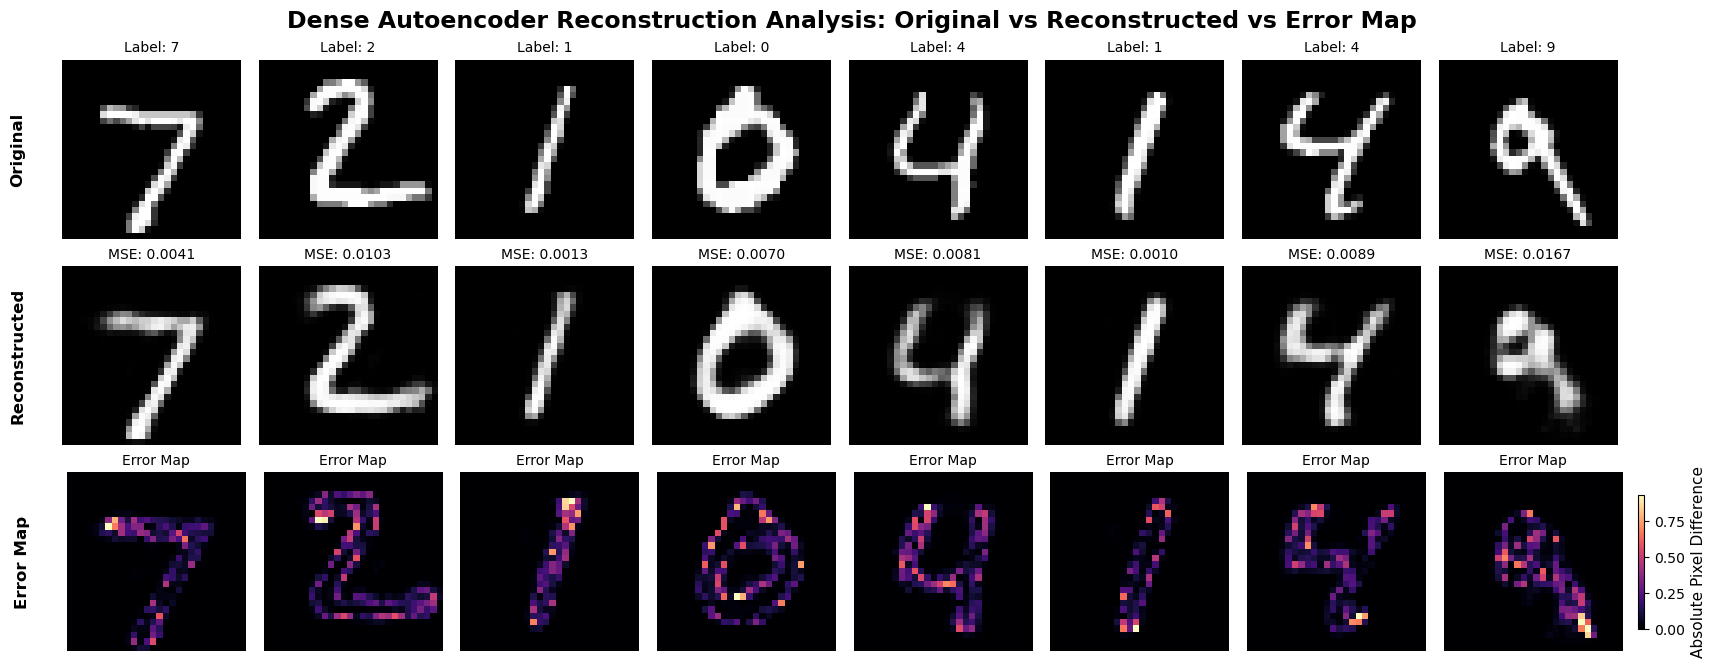

In [13]:
# ============================================================
# Step 11: Visualize reconstruction error maps
# ============================================================

# Number of images to display
num_images = 8

# Select sample images
original_samples = x_test_norm[:num_images]
reconstructed_samples = reconstructed_images[:num_images]
sample_errors = reconstruction_errors[:num_images]
sample_labels = y_test[:num_images]

# Calculate absolute pixel-level error maps
# Each error map shows where the reconstruction differs from the original
error_maps = np.abs(original_samples - reconstructed_samples)

# Create a professional 3-row comparison grid
fig, axes = plt.subplots(
    nrows=3,
    ncols=num_images,
    figsize=(17, 6.5),
    constrained_layout=True
)

fig.suptitle(
    "Dense Autoencoder Reconstruction Analysis: Original vs Reconstructed vs Error Map",
    fontsize=17,
    fontweight="bold"
)

# Row 1: Original images
for i in range(num_images):
    axes[0, i].imshow(original_samples[i], cmap="gray")
    axes[0, i].set_title(f"Label: {sample_labels[i]}", fontsize=10)
    axes[0, i].axis("off")

# Row 2: Reconstructed images
for i in range(num_images):
    axes[1, i].imshow(reconstructed_samples[i], cmap="gray")
    axes[1, i].set_title(f"MSE: {sample_errors[i]:.4f}", fontsize=10)
    axes[1, i].axis("off")

# Row 3: Error maps
# Brighter areas show larger reconstruction differences
for i in range(num_images):
    img = axes[2, i].imshow(error_maps[i], cmap="magma")
    axes[2, i].set_title("Error Map", fontsize=10)
    axes[2, i].axis("off")

# Add clean row labels
row_labels = ["Original", "Reconstructed", "Error Map"]

for row_idx, label in enumerate(row_labels):
    axes[row_idx, 0].text(
        -0.25,
        0.5,
        label,
        fontsize=12,
        fontweight="bold",
        rotation=90,
        va="center",
        ha="center",
        transform=axes[row_idx, 0].transAxes
    )

# Add one shared colorbar for the error maps
cbar = fig.colorbar(
    img,
    ax=axes[2, :],
    shrink=0.75,
    pad=0.01
)

cbar.set_label(
    "Absolute Pixel Difference",
    fontsize=11
)

plt.show()

### Reconstruction Analysis — Conclusion

The dense autoencoder was able to reconstruct the main structure of most MNIST digits successfully.

The reconstruction error maps show that the model performs best on simpler digits such as **1**, while more complex digits such as **9**, **4**, and **2** produce larger reconstruction errors.

Most reconstruction loss appears around:
- thin strokes
- curved edges
- sharp boundaries
- handwritten shape variations

Overall, the model preserved the main digit identity, but some fine visual details were smoothed out during compression and reconstruction.

## Beginner Dense Autoencoder — Final Conclusion

In this notebook, we built a **dense autoencoder** on the MNIST dataset using the architecture:

`784 → 128 → 32 → 128 → 784`

### What was done
- Loaded the MNIST dataset
- Normalised pixel values from **0–255** to **0–1**
- Flattened each image from **28 × 28** to **784 values**
- Built and trained a dense autoencoder for **10 epochs**
- Plotted training and validation loss
- Compared original and reconstructed test images
- Visualised error maps to identify where reconstruction quality drops

### Key result
The model learned to reconstruct handwritten digits reasonably well.  
It preserved the **overall digit shape**, while losing some **fine details**, especially around curves, edges, and thin strokes.

### Final takeaway
A dense autoencoder can learn useful compressed representations of images, but because it flattens the image structure, its reconstructions are slightly blurry and less precise than what we expect from a convolutional autoencoder.